# Model Development & Evaluation
---

## Models Evaluated

| Model | Rationale |
|---|---|
| **Random Forest** | Ensemble of decision trees; handles mixed feature types, produces feature importances, robust to noise |
| **Decision Tree** | Interpretable baseline; shows how a single tree performs |
| **Logistic Regression** | Linear baseline; demonstrates why more complex models are needed |

## 1. Setup

In [1]:
import json
import pickle , warnings
import os
import random
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.ensemble import RandomForestClassifier , VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.utils import shuffle
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay, roc_curve, auc
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette ='flare', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120})

models_dir = '/Users/wadalisam/Documents/GitHub/insider-threat-detector/models/'
figures_dir = '/Users/wadalisam/Documents/GitHub/insider-threat-detector/figures/'
os.makedirs(figures_dir, exist_ok=True)

#seed = random.randint(0,100)
#print(seed)
random_state = 42
print('Setup Complete')

Setup Complete


## 2. Load Preprocessed Data

In [2]:
with open(f'{models_dir}splits.pkl', 'rb') as f:
    splits = pickle.load(f)

with open(f'{models_dir}feature_names.pkl', 'rb') as f:
    feature_names = pickle.load(f)

X_train = splits['X_train']
X_train_sc = splits['X_train_sc']
y_train     = splits['y_train']
X_test      = splits['X_test']
y_test      = splits['y_test']

with open(f'{models_dir}scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

X_test_sc = scaler.transform(X_test)  # transform only — never fit on test data

print(f'Training set: {X_train.shape} | Test set: {X_test.shape}')
print(f'Features: {feature_names}')

Training set: (179564, 20) | Test set: (23723, 20)
Features: ['employee_department', 'employee_campus', 'employee_position', 'employee_seniority_years', 'is_contractor', 'employee_classification', 'has_foreign_citizenship', 'has_criminal_record', 'has_medical_history', 'employee_origin_country', 'total_printed_pages', 'num_printed_pages_off_hours', 'total_files_burned', 'burned_from_other', 'is_abroad', 'trip_day_number', 'hostility_country_level', 'num_entries', 'num_unique_campus', 'entry_during_weekend']


## 3. Model Configuration

In [3]:
#-------------------------Base models-------------------------------------------------------
rf = RandomForestClassifier(n_estimators=100, random_state=random_state,
                             n_jobs=-1, class_weight='balanced')
dt = DecisionTreeClassifier(random_state=random_state, max_depth=12,
                             class_weight='balanced')
lr = LogisticRegression(max_iter=500, random_state=random_state,
                         class_weight='balanced')

# LR wrapped in its own scaler so ensembles all receive raw X_train
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr',     LogisticRegression(max_iter=500, random_state=random_state,
                                   class_weight='balanced'))
])

model_configs = {
    # ----------------------------Singular models----------------------------------------------------------
    'Random Forest': {
        'model':  RandomForestClassifier(n_estimators=100, random_state=random_state,
                                          n_jobs=-1, class_weight='balanced'),
        'scaled': False
    },
    'Decision Tree': {
        'model':  DecisionTreeClassifier(random_state=random_state, max_depth=12,
                                          class_weight='balanced'),
        'scaled': False
    },
    'Logistic Regression': {
        'model':  LogisticRegression(max_iter=500, random_state=random_state,
                                      class_weight='balanced'),
        'scaled': True
    },

    # ----------------------------Voting ensembles-------------------------------------------
    'RF + DT': {
        'model':  VotingClassifier(estimators=[('rf', rf), ('dt', dt)],
                                    voting='soft'),
        'scaled': False
    },
    'RF + LR': {
        'model':  VotingClassifier(estimators=[('rf', rf), ('lr', lr_pipe)],
                                    voting='soft'),
        'scaled': False
    },
    'DT + LR': {
        'model':  VotingClassifier(estimators=[('dt', dt), ('lr', lr_pipe)],
                                    voting='soft'),
        'scaled': False
    },
    'RF + DT + LR': {
        'model':  VotingClassifier(estimators=[('rf', rf), ('dt', dt), ('lr', lr_pipe)],
                                    voting='soft'),
        'scaled': False
    },
}

## 4. Train Models

In [4]:
#----------------------Training loop -----------------------------------------------------
n_runs = 10

run_results = {name: {'f1': [], 'recall': [], 'precision': [], 'accuracy': [], 'auc': []}
               for name in model_configs}

# Stores the final run's artifacts for plotting
final_artifacts = {}

for run in range(n_runs):
    print(f'\n---------------Run {run + 1}/{n_runs}-----------------------------')

    X_train_shuf, y_train_shuf = shuffle(X_train, y_train, random_state=run)
    X_train_sc_shuf = scaler.transform(X_train_shuf)

    for name, cfg in model_configs.items():
        model = clone(cfg['model'])

        X_tr = X_train_sc_shuf if cfg['scaled'] else X_train_shuf
        X_te = X_test_sc       if cfg['scaled'] else X_test

        model.fit(X_tr, y_train_shuf)
        y_pred = model.predict(X_te)
        y_prob = model.predict_proba(X_te)[:, 1]

        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc_score   = auc(fpr, tpr)

        run_results[name]['f1'].append(f1_score(y_test, y_pred))
        run_results[name]['recall'].append(recall_score(y_test, y_pred))
        run_results[name]['precision'].append(precision_score(y_test, y_pred))
        run_results[name]['accuracy'].append(accuracy_score(y_test, y_pred))
        run_results[name]['auc'].append(auc_score)

        print(f'  {name:<20} F1={f1_score(y_test, y_pred):.4f}  Recall={recall_score(y_test, y_pred):.4f}')

        # Overwrite each run — final iteration keeps the last run's artifacts
        if run == n_runs - 1:
            final_artifacts[name] = {
                'model':  model,
                'y_pred': y_pred,
                'cm':     confusion_matrix(y_test, y_pred),
                'fpr':    fpr,
                'tpr':    tpr,
                'auc':    auc_score,
                'f1':     f1_score(y_test, y_pred),
                'recall': recall_score(y_test, y_pred),
                'precision': precision_score(y_test, y_pred),
                'accuracy':  accuracy_score(y_test, y_pred),
            }

# ── Summarise across all runs ──────────────────────────────────────────────────
print('\n\n=== Average Performance over 10 Runs ===')
summary_rows = []
for name, metrics in run_results.items():
    summary_rows.append({
        'Model':          name,
        'F1 Mean':        round(np.mean(metrics['f1']), 4),
        'F1 Std':         round(np.std(metrics['f1']),  4),
        'Recall Mean':    round(np.mean(metrics['recall']), 4),
        'Recall Std':     round(np.std(metrics['recall']),  4),
        'Precision Mean': round(np.mean(metrics['precision']), 4),
        'AUC Mean':       round(np.mean(metrics['auc']), 4),
    })

summary_df = pd.DataFrame(summary_rows).set_index('Model')
print(summary_df.to_string())

best_name        = summary_df['F1 Mean'].idxmax()
best_recall_name = summary_df['Recall Mean'].idxmax()
print(f'\nBest model by F1:     {best_name}  (mean F1={summary_df.loc[best_name, "F1 Mean"]:.4f})')
print(f'Best model by Recall: {best_recall_name}  (mean Recall={summary_df.loc[best_recall_name, "Recall Mean"]:.4f})')



---------------Run 1/10-----------------------------
  Random Forest        F1=0.7346  Recall=0.7964
  Decision Tree        F1=0.4832  Recall=0.7635
  Logistic Regression  F1=0.3453  Recall=0.7118
  RF + DT              F1=0.7010  Recall=0.7933
  RF + LR              F1=0.7120  Recall=0.8042
  DT + LR              F1=0.5814  Recall=0.7384
  RF + DT + LR         F1=0.6938  Recall=0.7800

---------------Run 2/10-----------------------------
  Random Forest        F1=0.7349  Recall=0.7956
  Decision Tree        F1=0.4832  Recall=0.7635
  Logistic Regression  F1=0.3453  Recall=0.7118
  RF + DT              F1=0.6987  Recall=0.7909
  RF + LR              F1=0.7124  Recall=0.8003
  DT + LR              F1=0.5814  Recall=0.7384
  RF + DT + LR         F1=0.6910  Recall=0.7776

---------------Run 3/10-----------------------------
  Random Forest        F1=0.7353  Recall=0.7940
  Decision Tree        F1=0.4832  Recall=0.7635
  Logistic Regression  F1=0.3453  Recall=0.7118
  RF + DT             

## 5. Performance Comparison

Model Performance Comparison (averaged over 10 runs, malicious class):
                     Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)     AUC
Model                                                                             
Random Forest               96.91          68.28       79.55         73.49  0.9774
Decision Tree               91.21          35.34       76.35         48.32  0.8883
Logistic Regression         85.47          22.79       71.18         34.53  0.8597
RF + DT                     96.36          62.86       79.22         70.09  0.9662
RF + LR                     96.50          64.00       80.02         71.12  0.9626
DT + LR                     94.28          47.94       73.84         58.14  0.9162
RF + DT + LR                96.29          62.45       77.92         69.33  0.9646


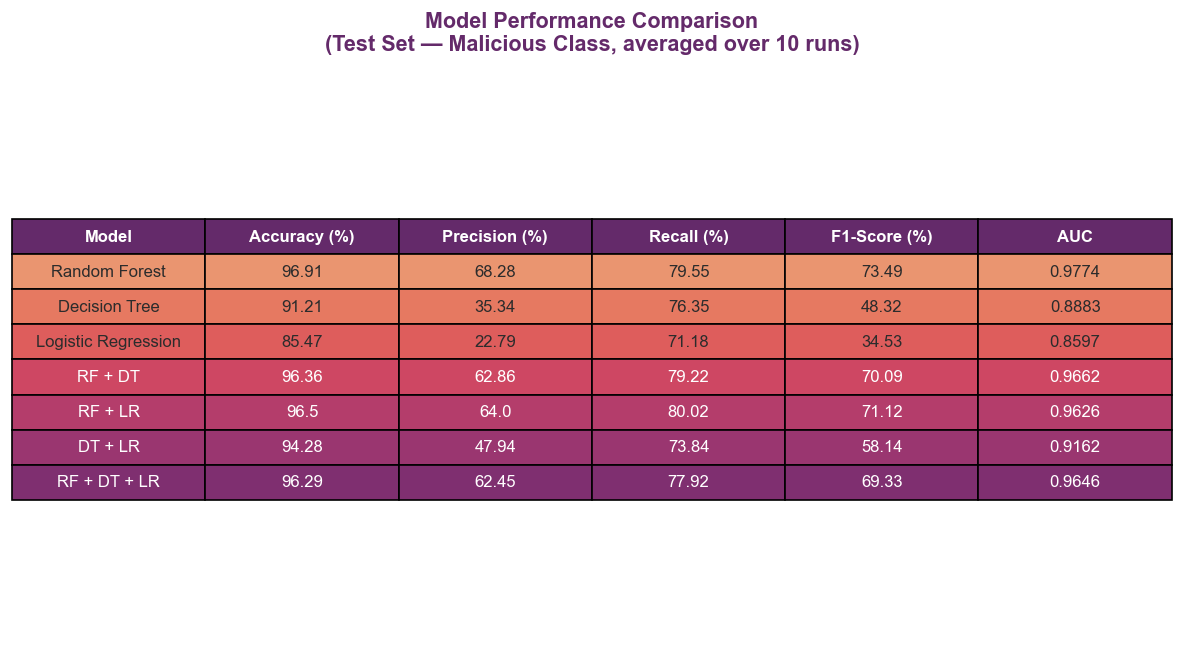

Saved to: /Users/wadalisam/Documents/GitHub/insider-threat-detector/figures/


In [5]:
# ── Metrics table (averaged) ───────────────────────────────────────────────────
metrics_df = pd.DataFrame([
    {'Model':         name,
     'Accuracy (%)':  round(np.mean(run_results[name]['accuracy']) * 100, 2),
     'Precision (%)': round(np.mean(run_results[name]['precision']) * 100, 2),
     'Recall (%)':    round(np.mean(run_results[name]['recall']) * 100, 2),
     'F1-Score (%)':  round(np.mean(run_results[name]['f1']) * 100, 2),
     'AUC':           round(np.mean(run_results[name]['auc']), 4)}
    for name in run_results
]).set_index('Model')

print('Model Performance Comparison (averaged over 10 runs, malicious class):')
print(metrics_df.to_string())

# ── Styled table figure ────────────────────────────────────────────────────────
flare        = sns.color_palette("flare", len(metrics_df) + 1)
header_color = flare[-1]
row_colors   = flare[:-1]

fig, ax = plt.subplots(figsize=(10, len(metrics_df) * 0.6 + 1.5))
ax.axis('off')
cols = metrics_df.reset_index().columns.tolist()
data = metrics_df.reset_index().values.tolist()
table = ax.table(cellText=data, colLabels=cols, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.6)

for j in range(len(cols)):
    table[0, j].set_facecolor(header_color)
    table[0, j].set_text_props(color='white', fontweight='bold')

for i in range(1, len(data) + 1):
    row_color = row_colors[i - 1] if i - 1 < len(row_colors) else 'white'
    for j in range(len(cols)):
        table[i, j].set_facecolor(row_color)
        lum = 0.299*row_color[0] + 0.587*row_color[1] + 0.114*row_color[2]
        table[i, j].set_text_props(color='white' if lum < 0.5 else '#2c2c2c')

ax.set_title('Model Performance Comparison\n(Test Set — Malicious Class, averaged over 10 runs)',
             fontsize=13, fontweight='bold', pad=12, color=header_color)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'model_performance_comparison.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved to:", figures_dir)

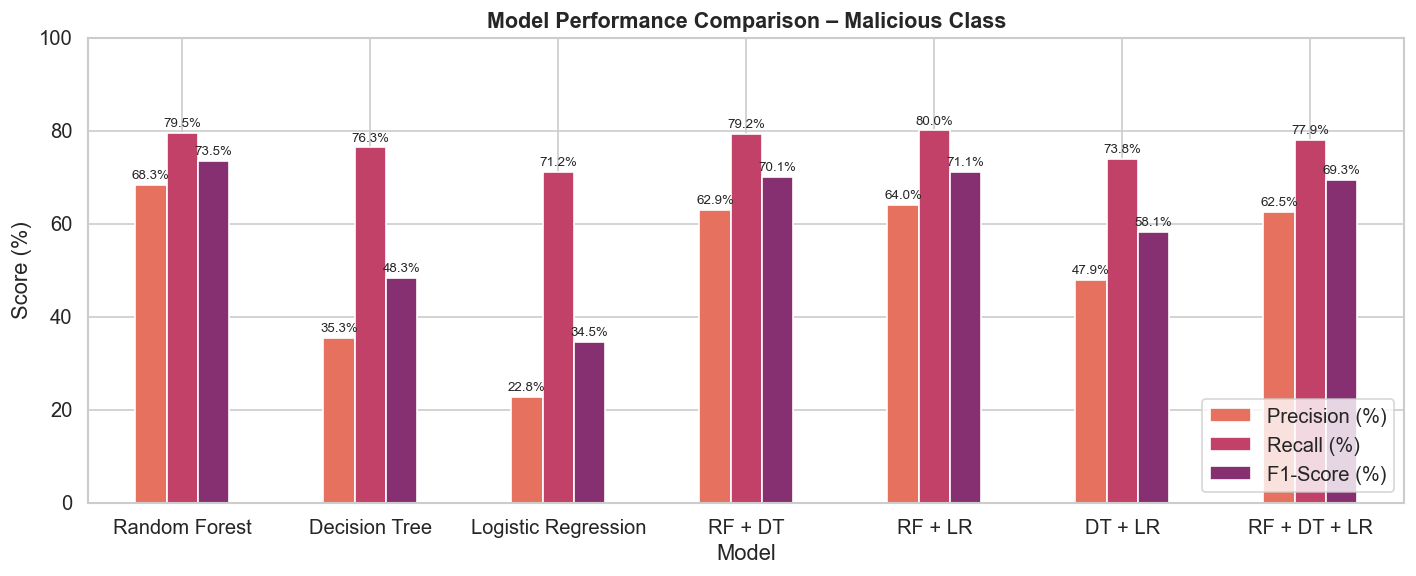

In [6]:
# ── Bar chart ──────────────────────────────────────────────────────────────────
n_models = len(metrics_df)
palette  = sns.color_palette('flare', n_colors=3)
fig, ax  = plt.subplots(figsize=(12, 5))
metrics_df[['Precision (%)', 'Recall (%)', 'F1-Score (%)']].plot(
    kind='bar', ax=ax, color=palette, edgecolor='white', rot=0)
ax.set_title('Model Performance Comparison – Malicious Class', fontweight='bold', fontsize=13)
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 100)
ax.legend(loc='lower right')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=8, padding=2)
plt.tight_layout()
plt.savefig(f'{figures_dir}performance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Confusion Matrices

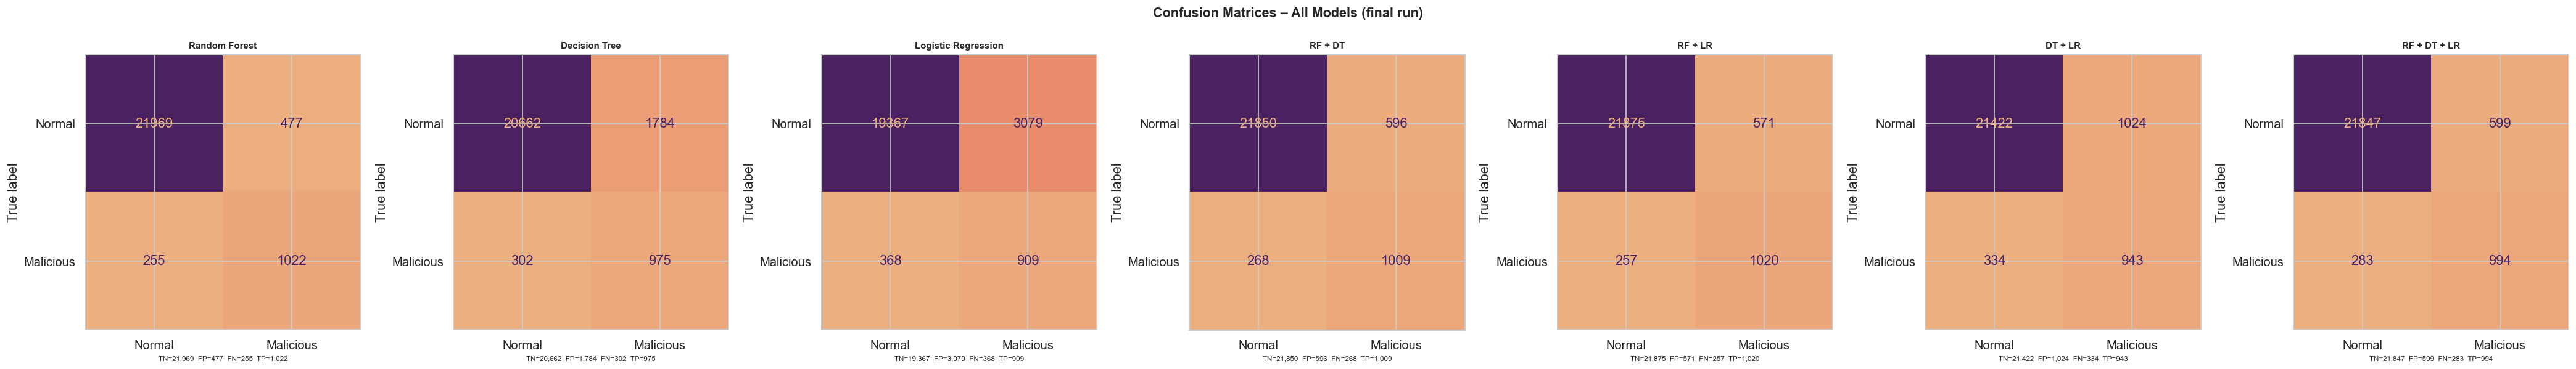

In [7]:
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 5))
for ax, (name, r) in zip(axes, final_artifacts.items()):
    disp = ConfusionMatrixDisplay(confusion_matrix=r['cm'],
                                   display_labels=['Normal', 'Malicious'])
    disp.plot(ax=ax, colorbar=False, cmap='flare')
    ax.set_title(name, fontweight='bold', fontsize=9)
    tn, fp, fn, tp = r['cm'].ravel()
    ax.set_xlabel(f'TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}', fontsize=7)
plt.suptitle('Confusion Matrices – All Models (final run)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{figures_dir}confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. ROC Curves

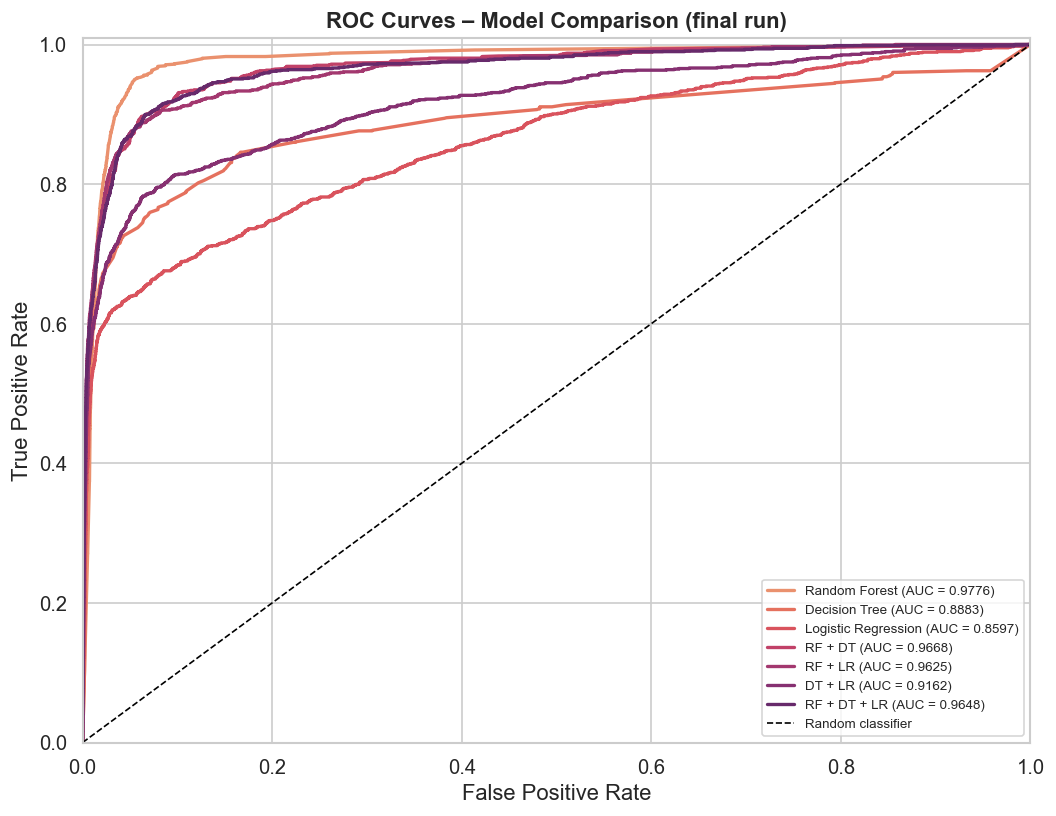

In [8]:
palette = sns.color_palette('flare', n_colors=n_models)
fig, ax = plt.subplots(figsize=(9, 7))
for (name, r), color in zip(final_artifacts.items(), palette):
    ax.plot(r['fpr'], r['tpr'], lw=2, color=color,
            label=f"{name} (AUC = {r['auc']:.4f})")
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves – Model Comparison (final run)', fontweight='bold')
ax.legend(loc='lower right', fontsize=8)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.01])
plt.tight_layout()
plt.savefig(f'{figures_dir}roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Detailed Report using F1 Score

In [9]:
best_name   = summary_df['F1 Mean'].idxmax()
best_result = final_artifacts[best_name]
best_model  = final_artifacts[best_name]['model']

print(f'=== Best Model by F1: {best_name} (mean F1={summary_df.loc[best_name, "F1 Mean"]:.4f}) ===')
print(classification_report(y_test, best_result['y_pred'],
                             target_names=['Normal (0)', 'Malicious (1)']))
tn, fp, fn, tp = best_result['cm'].ravel()
print(f'True Negatives  (correct Normal):     {tn:,}')
print(f'False Positives (Normal → Malicious): {fp:,}')
print(f'False Negatives (Malicious → Normal): {fn:,}')
print(f'True Positives  (correct Malicious):  {tp:,}')

=== Best Model by F1: Random Forest (mean F1=0.7349) ===
               precision    recall  f1-score   support

   Normal (0)       0.99      0.98      0.98     22446
Malicious (1)       0.68      0.80      0.74      1277

     accuracy                           0.97     23723
    macro avg       0.84      0.89      0.86     23723
 weighted avg       0.97      0.97      0.97     23723

True Negatives  (correct Normal):     21,969
False Positives (Normal → Malicious): 477
False Negatives (Malicious → Normal): 255
True Positives  (correct Malicious):  1,022


## 8. Detailed Report using Recall

In [10]:
best_recall_name   = summary_df['Recall Mean'].idxmax()
best_recall_result = final_artifacts[best_recall_name]
best_recall_model  = final_artifacts[best_recall_name]['model']

print(f'=== Best Model by Recall: {best_recall_name} (mean Recall={summary_df.loc[best_recall_name, "Recall Mean"]:.4f}) ===')
print(classification_report(y_test, best_recall_result['y_pred'],
                             target_names=['Normal (0)', 'Malicious (1)']))
tn, fp, fn, tp = best_recall_result['cm'].ravel()
print(f'True Negatives  (correct Normal):     {tn:,}')
print(f'False Positives (Normal → Malicious): {fp:,}')
print(f'False Negatives (Malicious → Normal): {fn:,}')
print(f'True Positives  (correct Malicious):  {tp:,}')

print('\n=== F1 winner vs Recall winner ===')
if best_name == best_recall_name:
    print(f'Both metrics agree — {best_name} is the best model overall.')
else:
    print(f'F1 winner:     {best_name:<20} F1={summary_df.loc[best_name, "F1 Mean"]:.4f}  Recall={summary_df.loc[best_name, "Recall Mean"]:.4f}')
    print(f'Recall winner: {best_recall_name:<20} F1={summary_df.loc[best_recall_name, "F1 Mean"]:.4f}  Recall={summary_df.loc[best_recall_name, "Recall Mean"]:.4f}')
    print(f'\nFor insider threat detection, {best_recall_name} is recommended')
    print('due to the higher cost of missing a real threat (false negative).')

=== Best Model by Recall: RF + LR (mean Recall=0.8002) ===
               precision    recall  f1-score   support

   Normal (0)       0.99      0.97      0.98     22446
Malicious (1)       0.64      0.80      0.71      1277

     accuracy                           0.97     23723
    macro avg       0.81      0.89      0.85     23723
 weighted avg       0.97      0.97      0.97     23723

True Negatives  (correct Normal):     21,875
False Positives (Normal → Malicious): 571
False Negatives (Malicious → Normal): 257
True Positives  (correct Malicious):  1,020

=== F1 winner vs Recall winner ===
F1 winner:     Random Forest        F1=0.7349  Recall=0.7955
Recall winner: RF + LR              F1=0.7112  Recall=0.8002

For insider threat detection, RF + LR is recommended
due to the higher cost of missing a real threat (false negative).


## 9. Save Model

In [11]:
#-----------Save the best model (by F1)-----------------------------------------------
with open(f'{models_dir}best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print(f'Best model ({best_name}) saved to {models_dir}best_model.pkl')
print(f'Model type: {type(best_model).__name__}')

# Save a human-readable record of what was saved
model_record = {
    'best_model_name': best_name,
    'model_type':      type(best_model).__name__,
    'f1':              round(best_result['f1'], 4),
    'recall':          round(best_result['recall'], 4),
    'precision':       round(best_result['precision'], 4),
    'accuracy':        round(best_result['accuracy'], 4),
    'auc':             round(best_result['auc'], 4),
}

with open(f'{models_dir}best_model_info.json', 'w') as f:
    json.dump(model_record, f, indent=2)

Best model (Random Forest) saved to /Users/wadalisam/Documents/GitHub/insider-threat-detector/models/best_model.pkl
Model type: RandomForestClassifier


In [12]:
#-----------Save the best model (by Recall)-----------------------------------------------
with open(f'{models_dir}recall_model.pkl', 'wb') as f:
    pickle.dump(best_recall_model, f)

print(f'Best recall model ({best_recall_name}) saved to {models_dir}recall_model.pkl')
print(f'Model type: {type(best_recall_model).__name__}')

recall_model_record = {
    'best_model_name': best_recall_name,
    'model_type':      type(best_recall_model).__name__,
    'f1':              round(best_recall_result['f1'], 4),
    'recall':          round(best_recall_result['recall'], 4),
    'precision':       round(best_recall_result['precision'], 4),
    'accuracy':        round(best_recall_result['accuracy'], 4),
    'auc':             round(best_recall_result['auc'], 4),
}

with open(f'{models_dir}recall_model_info.json', 'w') as f:
    json.dump(recall_model_record, f, indent=2)

print(json.dumps(recall_model_record, indent=2))

Best recall model (RF + LR) saved to /Users/wadalisam/Documents/GitHub/insider-threat-detector/models/recall_model.pkl
Model type: VotingClassifier
{
  "best_model_name": "RF + LR",
  "model_type": "VotingClassifier",
  "f1": 0.7113,
  "recall": 0.7987,
  "precision": 0.6411,
  "accuracy": 0.9651,
  "auc": 0.9625
}
